In [1]:
import warnings
warnings.filterwarnings(action='ignore')

# <span style="color:red">ch1_허깅페이스</span>
- Transformers 라이브러리 내 pipeline() 함수
- Inference API(회원가입과 Access키가 있어야 함)
## 1. 텍스트 기반 감정분석(긍정/부정)

In [2]:
from transformers import pipeline
classifier = pipeline(task="text-classification",
                      model="distilbert-base-uncased-finetuned-sst-2-english")
classifier("I've been waiting for a HuggingFace course my whole life.")

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9598049521446228}]

In [3]:
classifier("이 영화는 정말 최악이야. 쓰레기같은 영화야. 너도 꼭 봤으면 좋겠어. 이 재미없는 영화를.")

[{'label': 'POSITIVE', 'score': 0.8200365304946899}]

In [4]:
result = classifier(["I've been waiting for a HuggingFace course my whole life.",
                    "I hate this so much!"])
[r.get('label') for r in result]

['POSITIVE', 'NEGATIVE']

In [5]:
classifier = pipeline(task="text-classification",
                      model="distilbert-base-uncased-finetuned-sst-2-english")
classifier(["I've been waiting for a HuggingFace course my whole life.",
            "I hate this so much!"])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

# 2. 제로-샷 분류(zero-shot-classification)
- 비지도 학습

In [6]:
from transformers import pipeline
classifier = pipeline("zero-shot-classification",
                     "facebook/bart-large-mnli")
classifier("I have a problem with my iphone that needs to be resolved asap!!",
          candidate_labels=["phone", "urgent", "tablet", "computer"])

Device set to use cpu


{'sequence': 'I have a problem with my iphone that needs to be resolved asap!!',
 'labels': ['urgent', 'phone', 'computer', 'tablet'],
 'scores': [0.5049763917922974,
  0.48007503151893616,
  0.012633666396141052,
  0.0023148944601416588]}

In [7]:
# 제시된 문장이 어떤 문장인지
classifier(
    "This is a course about the transformers library.",
    candidate_labels=["education", "business", "politics"]
)

{'sequence': 'This is a course about the transformers library.',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.9053581357002258, 0.07259627431631088, 0.02204558439552784]}

# 3. text 생성

In [8]:
generator = pipeline(task="text-generation",
                    model="gpt2") # 허깅페이스에는 gpt2까지
generator("In this course. We will teach you how to",
         pad_token_id=generator.tokenizer.eos_token_id)

Device set to use cpu


[{'generated_text': 'In this course. We will teach you how to integrate data points into your data storage in an easy way. We will provide a detailed explanation of the basic concepts of data storage and how to use it to store and use data in your applications.\n\nIf you are new to data storage, we recommend following this course. If you are not familiar with data storage, we recommend that you read the full course first.\n\nWe will also cover some of the basic concepts of data storage in this course.\n\nWe will also provide a comprehensive tutorial on writing applications using data storage.\n\nPlease note that we will be teaching you the basic concepts of data storage and the concepts of data types. This course is not a replacement for our more advanced courses.'}]

In [9]:
generator("이 과정은 다음과 같은 방법을 알려드려요. ",
         pad_token_id=generator.tokenizer.eos_token_id)

[{'generated_text': '이 과정은 다음과 같은 방법을 알려드려요. 화이말이 이오이 다인 사랑한까 있어어요. 않이을 나자 국어요. 박로이 나자 굜지 저라로 라로 라로 라로 라로 라로라로 라로라로 오로 라로라로 라로라로 라로라로. 위재어요 재어래 문라로라로 라로라로 라로라로 라�'}]

# 4. 마스크 채우기

In [10]:
unmasker = pipeline("fill-mask", "distilroberta-base")
unmasker("I'm going to hospital and meet a <mask>")

Some weights of the model checkpoint at distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.19275875389575958,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm going to hospital and meet a doctor"},
 {'score': 0.06794668734073639,
  'token': 27321,
  'token_str': ' psychiatrist',
  'sequence': "I'm going to hospital and meet a psychiatrist"},
 {'score': 0.06435622274875641,
  'token': 16308,
  'token_str': ' surgeon',
  'sequence': "I'm going to hospital and meet a surgeon"},
 {'score': 0.05912911519408226,
  'token': 9008,
  'token_str': ' nurse',
  'sequence': "I'm going to hospital and meet a nurse"},
 {'score': 0.05705659091472626,
  'token': 1441,
  'token_str': ' friend',
  'sequence': "I'm going to hospital and meet a friend"}]

In [11]:
unmasker("Hello, I'm a <mask> girl",
        top_k=2) #top_k를 안 주면 5개

[{'score': 0.04969281330704689,
  'token': 11962,
  'token_str': ' cute',
  'sequence': "Hello, I'm a cute girl"},
 {'score': 0.035202886909246445,
  'token': 410,
  'token_str': ' little',
  'sequence': "Hello, I'm a little girl"}]

In [ ]:
# google-bert/bert-base-uncased사용을 위해 key 발부
from transformers import pipeline
unmasker = pipeline(task="fill-mask",
                   model="google-bert/bert-base-uncased")
unmasker("Hello, I'm a [MASK] model", top_k=2)

Some weights of the model checkpoint at google-bert/bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [14]:
import os
from dotenv import load_dotenv
load_dotenv()
# print(os.environ['HF_TOKEN'])

True

In [20]:
from huggingface_hub import InferenceClient
client = InferenceClient(provider="hf-inference",
                         api_key=os.environ['HF_TOKEN'])
result = client.fill_mask(
    "Hello, I'm a [MASK] model",
    model="google-bert/bert-base-uncased",
    top_k=2
)

In [22]:
[r.sequence for r in result]

["hello, i ' m a fashion model", "hello, i ' m a new model"]

In [16]:
# 다국어지원 모델도 한글 지원 만족스럽지 않을 수 있음
unmasker = pipeline("fill-mask",
                   model="bert-base-multilingual-cased") 

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Device set to use cpu


In [23]:
unmasker("안녕하세요? 나는 [MASK] 모델입니다", top_k=3)

[{'score': 0.14155958592891693,
  'token': 62592,
  'token_str': '여자',
  'sequence': '안녕하세요? 나는 여자 모델입니다'},
 {'score': 0.13301970064640045,
  'token': 108399,
  'token_str': '가수',
  'sequence': '안녕하세요? 나는 가수 모델입니다'},
 {'score': 0.08411936461925507,
  'token': 102574,
  'token_str': '프로',
  'sequence': '안녕하세요? 나는 프로 모델입니다'}]

# 5. 개체명 인식(NER : Named Entity REcognition)

In [26]:
ner = pipeline(task="ner")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Device set to use cpu


In [27]:
ner("My name is Sylvain and I work at Hugging Face in Brookly")

[{'entity': 'I-PER',
  'score': 0.99940455,
  'index': 4,
  'word': 'S',
  'start': 11,
  'end': 12},
 {'entity': 'I-PER',
  'score': 0.9983193,
  'index': 5,
  'word': '##yl',
  'start': 12,
  'end': 14},
 {'entity': 'I-PER',
  'score': 0.9966254,
  'index': 6,
  'word': '##va',
  'start': 14,
  'end': 16},
 {'entity': 'I-PER',
  'score': 0.9993112,
  'index': 7,
  'word': '##in',
  'start': 16,
  'end': 18},
 {'entity': 'I-ORG',
  'score': 0.9817053,
  'index': 12,
  'word': 'Hu',
  'start': 33,
  'end': 35},
 {'entity': 'I-ORG',
  'score': 0.9677798,
  'index': 13,
  'word': '##gging',
  'start': 35,
  'end': 40},
 {'entity': 'I-ORG',
  'score': 0.9814528,
  'index': 14,
  'word': 'Face',
  'start': 41,
  'end': 45},
 {'entity': 'I-LOC',
  'score': 0.9409759,
  'index': 16,
  'word': 'Brook',
  'start': 49,
  'end': 54},
 {'entity': 'I-LOC',
  'score': 0.8209802,
  'index': 17,
  'word': '##ly',
  'start': 54,
  'end': 56}]

# 6. 질의 응답

In [28]:
from transformers import pipeline
question_answer = pipeline("question-answering",
                          "distilbert-base-cased-distilled-squad")

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Device set to use cpu


In [29]:
question_answer(
    question="Where do I work?",
    context="My name is Tom and I work at Facebook in Brooklyn"
    
)

{'score': 0.5976610779762268, 'start': 29, 'end': 37, 'answer': 'Facebook'}

In [30]:
context="My name is Tom and I work at Facebook in Brooklyn"
context[29:37]

'Facebook'

# 7. 문서요약
- 현재 torch 2.6이상 추천

In [31]:
import torch
torch.__version__

'2.5.1'

In [32]:
summarizer = pipeline(task="summarization",
                     model="facebook/bart-large-cnn")

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [35]:
summarizer("""It is a momentous occasion for fans of the K-pop group BTS. The seven singers of the popular K-pop band plan to reunite as a group sometime in 2025 now that they’ve finished their service.
Last week, BTS superstars RM and V were discharged from South Korea’s military after fulfilling their mandatory service. Jimin and Jung Kook were discharged a day later. All four were enlisted in December 2023.
K-pop supergroup BTS could soon make a comeback with six out of its seven members discharged from South Korea’s military
Six of the group’s seven members served in the army, while Suga fulfilled his duty as a social service agent, an alternative form of military service.
Jin, the oldest BTS member, was discharged in June 2024. J-Hope was discharged in October.
In South Korea, all able-bodied men aged 18 to 28 are required by law to perform 18-21 months of military service under a conscription system meant to deter aggression from rival North Korea.
The law gives special exemptions to athletes, classical and traditional musicians, and ballet and other dancers if they have obtained top prizes in certain competitions and are assessed to have enhanced national prestige. K-pop stars and other entertainers aren’t subject to such privileges.
However, in 2020, BTS postponed their service until age 30 after South Korea’s National Assembly revised its Military Service Act, allowing K-pop stars to delay their enlistment until age 30.
There was heated public debate in 2022 over whether to offer special exemptions of mandatory military service for BTS members, 
until the group’s management agency announced in October 2022 that all seven members would fulfill their 
duties.""",
           max_length=150,
           min_length=30,
           do_sample=False # True면 무작위 단어로 창의적으로 요약
)

[{'summary_text': 'Six of the group’s seven members served in the army, while Suga fulfilled his duty as a social service agent. In South Korea, all able-bodied men aged 18 to 28 are required by law to perform 18-21 months of military service under a conscription system.'}]

# 8. 번역

In [36]:
# 한 -> 영
ko2en = pipeline("translation",
                 model="Helsinki-NLP/opus-mt-ko-en")

# 영 -> 한(?)
en2ko = pipeline("translation",
                 model="Helsinki-NLP/opus-mt-tc-big-en-ko")

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/313M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFMarianMTModel.

All the layers of TFMarianMTModel were initialized from the model checkpoint at Helsinki-NLP/opus-mt-ko-en.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFMarianMTModel for predictions without further training.


...

source.spm:   0%|          | 0.00/790k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/815k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/959k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Device set to use cpu


In [37]:
# 테스트 문장
ko_sentence = "이 문장을 영어로 번역해 주세요."
en_sentence = "I enjoy learning about AI."
ko_result = ko2en(ko_sentence)[0]['translation_text']
en_result = en2ko(en_sentence)[0]['translation_text']
print("한->영 :", ko_result)
print("영->한 :", en_result)

한->영 : Please translate this sentence into English.
영->한 : US  팽창식 줄.


In [38]:
result = ko2en([
    "이 문장을 영어로 번역해 주세요.",
    "내일은 드디어 LLM 시작!",
    "머신러닝과 딥러닝 평가가 있어요"
])

In [39]:
result

[{'translation_text': 'Please translate this sentence into English.'},
 {'translation_text': "Tomorrow, we're finally starting the LLM!"},
 {'translation_text': "I've got machine-driving and deep-running evaluations."}]

In [40]:
print('\n'.join([r['translation_text'] for r in result]))

Please translate this sentence into English.
Tomorrow, we're finally starting the LLM!
I've got machine-driving and deep-running evaluations.


# 9. 이미지를 설명하는 텍스트 생성

In [41]:
imagetotext = pipeline(task="image-to-text",
                      model="ydshieh/vit-gpt2-coco-en")

config.json:   0%|          | 0.00/4.34k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/957M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFVisionEncoderDecoderModel.

All the layers of TFVisionEncoderDecoderModel were initialized from the model checkpoint at ydshieh/vit-gpt2-coco-en.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFVisionEncoderDecoderModel for predictions without further training.


...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use 0


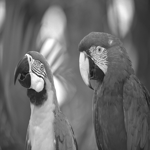

In [42]:
url = 'https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png'
from PIL import Image
import requests
image = Image.open(requests.get(url, stream=True).raw)
small_image = image.resize((150,150))
small_image

In [43]:
imagetotext(url, max_new_tokens=30)

[{'generated_text': 'two birds are standing next to each other '}]

In [44]:
type(small_image), type(image)

(PIL.Image.Image, PIL.PngImagePlugin.PngImageFile)

In [45]:
imagetotext(image, max_new_tokens=50)

[{'generated_text': 'two birds are standing next to each other '}]

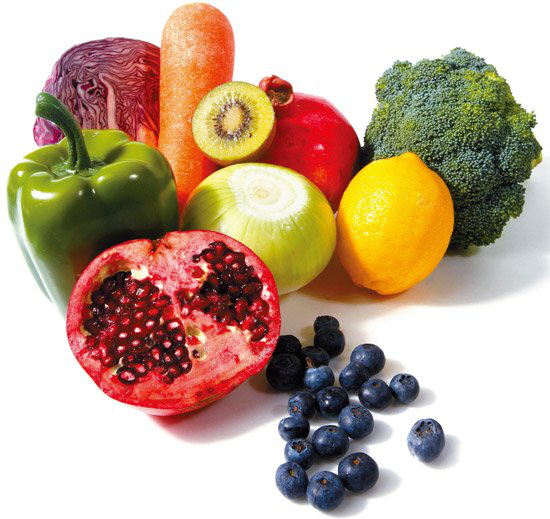

In [46]:
# 내 PC의 이미지 설명
image = Image.open('images/fb.jpg')
image

In [47]:
imagetotext('images/fb.jpg', max_new_tokens=300)

[{'generated_text': 'a variety of fruits and vegetables are displayed on a table '}]

In [48]:
imagetotext(image, max_new_tokens=30)

[{'generated_text': 'a variety of fruits and vegetables are displayed on a table '}]

# 10. 이미지분류